# Goal
The goal is to use a simple model to classify x-ray images in Keras, the notebook how to use the ```flow_from_dataframe``` to deal with messier datasets

In [96]:
# !pip install timm transformers datasets accelerate opencv-python scikit-learn

In [97]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt

import cv2
import math
from PIL import Image
from tqdm import tqdm

import timm
from sklearn.metrics import roc_auc_score
from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [98]:
all_xray_df = pd.read_csv('/kaggle/input/data/Data_Entry_2017.csv')

all_image_paths = {
    os.path.basename(x): x
    for x in glob('/kaggle/input/data/images*/*/*.png')  #? path tuyệt đối, khớp gốc với dòng CSV ở trên
}

print('Scans found:', len(all_image_paths), ', Total Headers', all_xray_df.shape[0])
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

Scans found: 112120 , Total Headers 112120


In [99]:
all_xray_df["Patient Age"] = all_xray_df["Patient Age"].astype(np.int16)  #! astype trả bản copy, không gán lại thì cột vẫn nguyên dtype cũ
all_xray_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,/kaggle/input/data/images_001/images/00000001_...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,/kaggle/input/data/images_001/images/00000001_...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,/kaggle/input/data/images_001/images/00000001_...
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,/kaggle/input/data/images_001/images/00000002_...
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,/kaggle/input/data/images_001/images/00000003_...


# Preprocessing Labels
Here we take the labels and make them into a more clear format. The primary step is to see the distribution of findings and then to convert them to simple binary labels

In [100]:
label_counts = all_xray_df['Finding Labels'].value_counts()[:15]
# fig, ax1 = plt.subplots(1,1,figsize = (12, 8))
# ax1.bar(np.arange(len(label_counts))+0.5, label_counts)
# ax1.set_xticks(np.arange(len(label_counts))+0.5)
# _ = ax1.set_xticklabels(label_counts.index, rotation = 90)
label_counts

Finding Labels
No Finding                  60361
Infiltration                 9547
Atelectasis                  4215
Effusion                     3955
Nodule                       2705
Pneumothorax                 2194
Mass                         2139
Effusion|Infiltration        1603
Atelectasis|Infiltration     1350
Consolidation                1310
Atelectasis|Effusion         1165
Pleural_Thickening           1126
Cardiomegaly                 1093
Emphysema                     892
Infiltration|Nodule           829
Name: count, dtype: int64

In [102]:
from itertools import chain

all_xray_df["Finding Labels"] = all_xray_df["Finding Labels"].map(lambda x: x.replace("No Finding", ""))

label_sets = all_xray_df["Finding Labels"].map(lambda f: {t for t in f.split("|") if t})  #? tách token 1 lần rồi tái dùng, thay vì split lại 14 lượt trong vòng for

all_labels = sorted(set(chain.from_iterable(label_sets)))
print("All Labels ({}): {}".format(len(all_labels), all_labels))

for c_label in all_labels:
    #! exact token match, KHÔNG dùng `c_label in finding` — substring match hiện đúng với NIH-14 chỉ vì tình cờ không nhãn nào là substring của nhãn khác
    all_xray_df[c_label] = label_sets.map(lambda s, c=c_label: 1.0 if c in s else 0.0).astype(np.float32)

all_xray_df["path"].sample(3)

All Labels (14): ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


3384     /kaggle/input/data/images_001/images/00000896_...
46969    /kaggle/input/data/images_006/images/00011973_...
50606    /kaggle/input/data/images_006/images/00012834_...
Name: path, dtype: object

In [103]:
all_xray_df.iloc[37495], all_labels

(Image Index                                                     00009889_007.png
 Finding Labels                                             Atelectasis|Pneumonia
 Follow-up #                                                                    7
 Patient ID                                                                  9889
 Patient Age                                                                   24
 Patient Gender                                                                 M
 View Position                                                                 PA
 OriginalImage[Width                                                         2048
 Height]                                                                     2500
 OriginalImagePixelSpacing[x                                                0.168
 y]                                                                         0.168
 Unnamed: 11                                                                  NaN
 path           

### Clean categories
Since we have too many categories, we can prune a few out by taking the ones with only a few examples

In [104]:
# keep at least 1000 cases
MIN_CASES = 1000
all_labels = [c_label for c_label in all_labels if all_xray_df[c_label].sum()>MIN_CASES]
print('Clean Labels ({})'.format(len(all_labels)), 
      [(c_label,int(all_xray_df[c_label].sum())) for c_label in all_labels])

Clean Labels (13) [('Atelectasis', 11559), ('Cardiomegaly', 2776), ('Consolidation', 4667), ('Edema', 2303), ('Effusion', 13317), ('Emphysema', 2516), ('Fibrosis', 1686), ('Infiltration', 19894), ('Mass', 5782), ('Nodule', 6331), ('Pleural_Thickening', 3385), ('Pneumonia', 1431), ('Pneumothorax', 5302)]


# Prepare Training Data
Here we split the data into training and validation sets and create a single vector (disease_vec) with the 0/1 outputs for the disease status (what the model will try and predict)

In [105]:
disease_mat = all_xray_df[all_labels].to_numpy(np.float32)  #? (N, 13) — thay cho apply(axis=1) trả object array, nhanh hơn ~100x

all_xray_df["n_findings"] = disease_mat.sum(1)  #? sample weight chỉ cần tổng, không cần giữ cả vector
all_xray_df["disease_vec"] = list(disease_mat)  #? vẫn giữ cột cho phần CAM demo cuối notebook, nhưng giờ mỗi phần tử là np.float32 array thật

print(all_xray_df["n_findings"].value_counts().sort_index())

n_findings
0.0    60471
1.0    30926
2.0    14268
3.0     4826
4.0     1245
5.0      299
6.0       66
7.0       16
8.0        1
9.0        2
Name: count, dtype: int64


In [106]:
def read_txt_list(txt_path):
    with open(txt_path, "r") as f:
        items = [line.strip() for line in f.readlines()]

    items = [x for x in items if x != ""]
    return items

train_val_list_path = "/kaggle/input/data/train_val_list.txt"
test_list_path = "/kaggle/input/data/test_list.txt"

train_val_list = read_txt_list(train_val_list_path)
test_list = read_txt_list(test_list_path)

print("train_val:", len(train_val_list))
print("test:", len(test_list))

train_val_set = set(train_val_list)
test_set = set(test_list)

train_val_df = all_xray_df[all_xray_df["Image Index"].isin(train_val_set)].reset_index(drop=True)
test_df = all_xray_df[all_xray_df["Image Index"].isin(test_set)].reset_index(drop=True)

print("train_val_df:", train_val_df.shape)
print("test_df:", test_df.shape)

train_val: 86524
test: 25596
train_val_df: (86524, 29)
test_df: (25596, 29)


Check xem có ảnh nào trong txt nhưng không có trong df không:

In [107]:
df_image_set = set(all_xray_df["Image Index"].astype(str).values)

missing_train_val = train_val_set - df_image_set
missing_test = test_set - df_image_set

print("missing train_val:", len(missing_train_val))
print("missing test:", len(missing_test))

print("sample missing train_val:", list(missing_train_val)[:5])
print("sample missing test:", list(missing_test)[:5])

missing train_val: 0
missing test: 0
sample missing train_val: []
sample missing test: []


In [108]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=1604)

#! group theo Patient ID — NIH ~30k bệnh nhân / 112k ảnh, chia theo ảnh khiến cùng 1 người nằm cả train lẫn val và thổi phồng val AUC ~1.6 điểm
tr_idx, va_idx = next(gss.split(train_val_df, groups=train_val_df["Patient ID"]))

train_df = train_val_df.iloc[tr_idx].reset_index(drop=True)
valid_df = train_val_df.iloc[va_idx].reset_index(drop=True)

print("train", len(train_df), "| valid", len(valid_df))
print("patient overlap:", len(set(train_df["Patient ID"]) & set(valid_df["Patient ID"])))  #? phải ra 0
print("prevalence gap tối đa:", (train_df[all_labels].mean() - valid_df[all_labels].mean()).abs().max())
#? GroupShuffleSplit không stratify được — check gap này, dưới ~0.01 là chấp nhận, cao hơn thì đổi random_state

train 60444 | valid 26080
patient overlap: 0
prevalence gap tối đa: 0.005150645971298218


# Cache Dataset
chỉ chạy nếu chưa cache / preprocess trước

In [109]:

# import shutil

# CACHE_S = 256


# #@ Chọn thư mục cache có đủ chỗ trống, ưu tiên nơi không bị tính vào output quota
# #@ Raise nếu không chỗ nào đủ — tốt hơn là để memmap ghi nửa chừng rồi hết disk
# def pick_cache_dir(need_bytes):
#     for d in ["/kaggle/working","/kaggle/temp", "/tmp"]:  #? /kaggle/working là cuối cùng — nó bị commit làm output và giới hạn 20GB
#         os.makedirs(d, exist_ok=True)  #! đây là dòng thiếu — mode="w+" tạo file chứ không tạo parent dir

#         free = shutil.disk_usage(d).free
#         if free > need_bytes * 1.15:  #? chừa 15% headroom, đừng ghi sát trần disk
#             print(f"cache dir: {d} (free {free / 1e9:.1f}GB)")
#             return d

#     raise RuntimeError(f"không thư mục nào đủ {need_bytes / 1e9:.1f}GB")


# cache_df = all_xray_df.dropna(subset=["path"]).reset_index(drop=True)
# N_TOTAL = len(cache_df)

# CACHE_DIR = pick_cache_dir(N_TOTAL * CACHE_S * CACHE_S)

# CACHE_PATH = os.path.join(CACHE_DIR, f"xray_{CACHE_S}.u8")
# META_PATH = os.path.join(CACHE_DIR, f"xray_{CACHE_S}_index.npy")

In [110]:
# from multiprocessing import Pool
 
# cv2.setNumThreads(0)  #! bắt buộc — cv2 mặc định tự spawn thread, sẽ oversubscribe khi chạy trong Pool/DataLoader worker
 
 
# #@ Worker: decode + resize 1 chunk paths, ghi vào memmap tại offset tương ứng
# #@ Trả về (số ảnh ghi thành công, list path lỗi) để caller kiểm tra tính toàn vẹn
# def _fill_chunk(args):
#     start, paths, n_total = args

#     mm = np.memmap(CACHE_PATH, dtype=np.uint8, mode="r+", shape=(n_total, CACHE_S, CACHE_S))
#     ok, bad = 0, []

#     for k, p in enumerate(paths):
#         img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)

#         if img is None:  #! imread không raise khi file hỏng/sai path — phải tự check
#             bad.append(p)
#             continue

#         mm[start + k] = cv2.resize(img, (CACHE_S, CACHE_S), interpolation=cv2.INTER_AREA)
#         ok += 1

#     mm.flush()
#     del mm
#     return ok, bad
 
 
# #@ Build cache uint8 grayscale từ list path ảnh gốc, chạy song song trên toàn bộ core
# #@ Trả về dict {image_name -> row index trong memmap} để dataset tra cứu sau này
# #@ Idempotent: đã có cache thì load meta và return luôn
# def build_cache(paths, names, n_proc=4):
#     n = len(paths)
 
#     if os.path.exists(CACHE_PATH) and os.path.exists(META_PATH):
#         print("cache đã tồn tại, skip")
#         return {k: i for i, k in enumerate(np.load(META_PATH, allow_pickle=True))}
 
#     mm = np.memmap(CACHE_PATH, dtype=np.uint8, mode="w+", shape=(n, CACHE_S, CACHE_S))
#     del mm  #? tạo file rỗng đúng size trước, các worker sau đó mở mode="r+" ghi song song vào cùng file
 
#     chunk = 512
#     jobs = [(i, paths[i:i + chunk], n) for i in range(0, n, chunk)]
 
#     with Pool(n_proc) as pool:
#         done, all_bad = 0, []
#         for ok, bad in pool.imap_unordered(_fill_chunk, jobs):
#             done += ok
#             all_bad.extend(bad)
#             if done % 10240 < chunk:
#                 print(f"  {done}/{n}")

#     #! chỉ save meta khi mọi ảnh đều ghi được — sự tồn tại của META_PATH chính là cờ "cache hợp lệ" cho lần chạy sau
#     if all_bad:
#         raise RuntimeError(f"{len(all_bad)} ảnh lỗi, vd: {all_bad[:3]}")

#     np.save(META_PATH, np.array(names, dtype=object))
#     return {k: i for i, k in enumerate(names)}
 
 
# # ── chạy build ──
# cache_df = all_xray_df.dropna(subset=["path"]).reset_index(drop=True)
# name2row = build_cache(
#     paths=cache_df["path"].tolist(),
#     names=cache_df["Image Index"].tolist(),
#     n_proc=4,
# )

In [111]:
# print(len(all_image_paths))          # nếu ra 0 → glob không match được gì
# print(all_xray_df['path'].notna().sum())   # số ảnh map được

# Load Preprocessed Data

In [112]:
CACHE_S = 224
CACHE_DIR = "/kaggle/input/datasets/longphmchu/processed-xray-data"

CACHE_PATH = os.path.join(CACHE_DIR, "xray_256.u8")
META_PATH = os.path.join(CACHE_DIR, "xray_256_index.npy")

In [113]:
names = np.load(META_PATH, allow_pickle=True)

name2row = {
    name: i
    for i, name in enumerate(names)
}

# Create Data Generators
Here we make the data generators for loading and randomly transforming images

In [114]:
CFG = {
    "label_cols": list(all_labels),

    "backbone": "resnet50",      # thử: densenet121, convnext_tiny, efficientnet_b0
    "pretrained": True,
    "image_size": 224,
    "transition_dim": 1024,
    "pooling": "lse",            # "avg", "max", "lse"
    "lse_r": 10.0,

    "epochs": 20,
    "batch_size": 64,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "num_workers": 3,
}

In [115]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

OUT_S = 224
 
 
class XrayCachedDataset(Dataset):
    #@ Dataset đọc trực tiếp từ memmap uint8 đã pre-resize — không decode, không PIL, không pandas
    #@ Trả về tensor uint8 (1,224,224); việc float/normalize đẩy sang GPU để tiết kiệm CPU
    def __init__(self, df, name2row, label_cols, n_total, train=False):
        self.rows = np.array([name2row[n] for n in df["Image Index"]], dtype=np.int64)  #? resolve index 1 lần ở __init__, __getitem__ chỉ còn lookup mảng int
        self.labels = df[label_cols].to_numpy(dtype=np.float32)  #! convert sang numpy ngay — .iloc[idx] trên DataFrame mixed-dtype tốn ~1ms/sample dưới GIL
        self.labels = np.nan_to_num(self.labels, nan=0.0)
 
        self.n_total = n_total
        self.train = train
        self.mm = None  #! memmap phải mở lazy trong worker, mở ở __init__ sẽ bị pickle/fork sai handle
 
    def __len__(self):
        return len(self.rows)
 
    def __getitem__(self, idx):
        if self.mm is None:
            self.mm = np.memmap(CACHE_PATH, dtype=np.uint8, mode="r", shape=(self.n_total, CACHE_S, CACHE_S))
 
        img = self.mm[self.rows[idx]]
 
        if self.train:
            y = np.random.randint(0, CACHE_S - OUT_S + 1)
            x = np.random.randint(0, CACHE_S - OUT_S + 1)
            img = img[y:y + OUT_S, x:x + OUT_S]
 
            if np.random.rand() < 0.5:
                img = img[:, ::-1]  #? horizontal flip bằng negative stride — không copy, copy() phía dưới lo phần contiguous
        else:
            o = (CACHE_S - OUT_S) // 2
            img = img[o:o + OUT_S, o:o + OUT_S]  #? center crop cho val để deterministic
 
        return {
            "pixel_values": torch.from_numpy(np.ascontiguousarray(img)).unsqueeze(0),  #? giữ uint8: transfer PCIe nhẹ hơn float32 4 lần
            "labels": torch.from_numpy(self.labels[idx]),
        }
 



In [116]:
cache_df = all_xray_df.dropna(subset=["path"]).reset_index(drop=True)
N_TOTAL = len(cache_df)

train_ds = XrayCachedDataset(train_df, name2row, CFG["label_cols"], N_TOTAL, train=True)
val_ds = XrayCachedDataset(valid_df, name2row, CFG["label_cols"], N_TOTAL, train=False)
test_ds = XrayCachedDataset(test_df, name2row, CFG["label_cols"], N_TOTAL, train=False)

In [117]:


# Add weights for dataloader
def make_sample_weights_from_df(df, disease_vec_col, base_weight=0.04):
    """
    weight mỗi ảnh = số bệnh positive + base_weight
    """
    num_diseases = df[disease_vec_col].map(lambda v: np.sum(v))
    sample_weights = num_diseases.values + base_weight
    return torch.DoubleTensor(sample_weights)
    
train_weights = make_sample_weights_from_df(
    df=train_df,
    disease_vec_col = 'disease_vec',
    base_weight=0.04,
)

train_sampler = WeightedRandomSampler(
    weights=train_weights,
    num_samples=len(train_weights),
    replacement=True,
)

# Datasets and Dataloader
train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    sampler=train_sampler,
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True,
    persistent_workers=True,   # thêm dòng này
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True,
    persistent_workers=True,
)
len(train_ds), len(val_ds)

(60444, 26080)

# Model

In [118]:
class GlobalPool2d(nn.Module):
    def __init__(self, mode="lse", lse_r=10.0):
        super().__init__()
        assert mode in ["avg", "max", "lse"]
        self.mode = mode
        self.lse_r = lse_r

    def forward(self, x):
        if self.mode == "avg":
            return x.mean(dim=(-2, -1))

        if self.mode == "max":
            return x.amax(dim=(-2, -1))

        # Log-Sum-Exp pooling
        b, c, h, w = x.shape
        flat = x.flatten(2)
        m = flat.amax(dim=-1, keepdim=True)
        pooled = m + torch.log(torch.exp((flat - m) * self.lse_r).mean(dim=-1, keepdim=True)) / self.lse_r
        return pooled.view(b, c)

In [119]:
class ChestLocalizationModel(nn.Module):
    def __init__(
        self,
        num_classes,
        backbone_name="resnet50",
        pretrained=True,
        transition_dim=1024,
        pooling="lse",
        lse_r=10.0,
        dropout=0.0,
    ):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            features_only=True,
            out_indices=(-1,),
        )

        backbone_channels = self.backbone.feature_info.channels()[-1]

        # Transition layer: đưa activation từ pretrained model về dimension thống nhất
        self.transition = nn.Sequential(
            nn.Conv2d(backbone_channels, transition_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(transition_dim),
            nn.ReLU(inplace=True),
        )

        self.pool = GlobalPool2d(pooling, lse_r=lse_r)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        # Prediction layer
        self.classifier = nn.Linear(transition_dim, num_classes)

    def forward(self, pixel_values, return_features=False):
        features = self.backbone(pixel_values)[-1]
        transition_features = self.transition(features)
        pooled_features = self.pool(transition_features)
        logits = self.classifier(self.dropout(pooled_features))

        if return_features:
            return {
                "logits": logits,
                "transition_features": transition_features,
                "pooled_features": pooled_features,
            }

        return logits

In [120]:
_mean = torch.tensor(IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
_std = torch.tensor(IMAGENET_STD, device=device).view(1, 3, 1, 1)


#@ Chuyển batch uint8 (B,1,H,W) từ loader sang float32 (B,3,H,W) đã normalize, toàn bộ trên GPU
def to_gpu_float(x):
    x = x.to(device, non_blocking=True).float().div_(255)
    x = x.expand(-1, 3, -1, -1)  #? expand không copy — 3 kênh cùng trỏ vào 1 vùng nhớ, conv1 đọc bình thường
    return (x - _mean) / _std  #! không dùng sub_/div_ in-place ở đây — x là expanded view, ghi in-place lên nó là undefined behavior

In [121]:
model = ChestLocalizationModel(
    num_classes=len(CFG["label_cols"]),
    backbone_name=CFG["backbone"],
    pretrained=CFG["pretrained"],
    transition_dim=CFG["transition_dim"],
    pooling=CFG["pooling"],
    lse_r=CFG["lse_r"],
).to(device)

# if torch.cuda.device_count() > 1:
#     print(f"Using {torch.cuda.device_count()} GPUs")
#     model = nn.DataParallel(model)
#     print("train thành công trong nhiều GPU")

# model = model.to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
)
scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

/tmp/ipykernel_58/1636392100.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))


In [122]:
#@ Tính AUC từng lớp + mean, bỏ qua lớp không có đủ cả nhãn 0 lẫn 1 trong tập eval
#@ Trả về (mean_auc: float, per_class: dict) — bản cũ chỉ trả dict, làm hỏng `val_auc > best_auc` và f-string trong training loop
def auc_per_class(y_true, y_prob, verbose=True):
    out = {}

    for i, name in enumerate(CFG["label_cols"]):
        if len(np.unique(y_true[:, i])) < 2:
            continue  #? ROC không định nghĩa được khi chỉ có 1 class

        out[name] = roc_auc_score(y_true[:, i], y_prob[:, i])

    mean_auc = float(np.mean(list(out.values()))) if out else 0.0

    if verbose:
        for name, auc in sorted(out.items(), key=lambda t: t[1]):
            print(f"  {name:20s} {auc:.4f}")
        print(f"  {'── MEAN':20s} {mean_auc:.4f}")

    return mean_auc, out

In [123]:
#@ Train 1 epoch, trả về (avg_loss, mean_auc, per_class) — cùng shape return với validate_one_epoch
#@ Gom logits/labels cả epoch để tính AUC; train AUC ở đây tính trên phân phối đã resample bởi WeightedRandomSampler
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss, n_seen = 0.0, 0
    all_logits, all_labels = [], []

    pbar = tqdm(loader, desc="Train", leave=False)  #! bản cũ gọi pbar.set_postfix mà không hề tạo pbar → NameError ngay batch đầu

    for batch in pbar:
        pixel_values = to_gpu_float(batch["pixel_values"])
        labels = batch["labels"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):  #? đồng bộ API với validate_one_epoch, torch.cuda.amp.autocast đã deprecated
            logits = model(pixel_values)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = pixel_values.size(0)
        total_loss += loss.item() * bs
        n_seen += bs  #! bản cũ return total_loss / n_seen nhưng không bao giờ khai báo n_seen

        all_logits.append(logits.detach().float().cpu())  #? .float() trước khi rời GPU: dưới autocast logits là fp16, sigmoid fp16 mất precision ở đuôi phân phối
        all_labels.append(labels.detach().cpu())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    y_prob = torch.cat(all_logits).sigmoid().numpy()
    y_true = torch.cat(all_labels).numpy()

    mean_auc, per_class = auc_per_class(y_true, y_prob, verbose=False)

    return total_loss / n_seen, mean_auc, per_class

In [124]:
#@ Eval 1 epoch, trả về (avg_loss, mean_auc, per_class, y_true, y_prob)
#@ Trả kèm y_true/y_prob để dùng lại cho calibration và threshold tuning mà không phải forward lần nữa
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, verbose=True):
    model.eval()

    total_loss, n_seen = 0.0, 0
    all_logits, all_labels = [], []

    pbar = tqdm(loader, desc="Valid", leave=False)

    for batch in pbar:
        pixel_values = to_gpu_float(batch["pixel_values"])
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            logits = model(pixel_values)
            loss = criterion(logits, labels)

        bs = pixel_values.size(0)
        total_loss += loss.item() * bs
        n_seen += bs

        all_logits.append(logits.float().cpu())  #! .float() trước sigmoid, lý do như bên train
        all_labels.append(labels.cpu())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    y_prob = torch.cat(all_logits).sigmoid().numpy()
    y_true = torch.cat(all_labels).numpy()

    mean_auc, per_class = auc_per_class(y_true, y_prob, verbose=verbose)

    return total_loss / n_seen, mean_auc, per_class, y_true, y_prob

# Training loop

In [125]:
# best_auc = -1.0
# history = []

# for epoch in range(1, CFG["epochs"] + 1):
#     print(f"\nEpoch {epoch}/{CFG['epochs']}")

#     train_loss, train_auc, train_pc = train_one_epoch(
#         model=model,
#         loader=train_loader,
#         optimizer=optimizer,
#         criterion=criterion,
#         device=device,
#     )

#     val_loss, val_auc, val_pc, _, _ = validate_one_epoch(
#         model=model,
#         loader=val_loader,
#         criterion=criterion,
#         device=device,
#     )  #! validate trả 5 giá trị, unpack 2 sẽ ValueError

#     history.append({
#         "epoch": epoch,
#         "train_loss": train_loss,
#         "train_auc": train_auc,
#         "val_loss": val_loss,
#         "val_auc": val_auc,
#     })

#     print(
#         f"train_loss={train_loss:.4f} | "
#         f"train_auc={train_auc:.4f} | "
#         f"val_loss={val_loss:.4f} | "
#         f"val_auc={val_auc:.4f}"
#     )

#     torch.save({
#         "epoch": epoch,
#         "model": model.state_dict(),
#         "optimizer": optimizer.state_dict(),
#         "config": CFG,
#         "history": history,
#     }, "last_model.pt")

#     if val_auc > best_auc:
#         best_auc = val_auc

#         torch.save({
#             "epoch": epoch,
#             "model": model.state_dict(),
#             "optimizer": optimizer.state_dict(),
#             "config": CFG,
#             "history": history,
#             "best_auc": best_auc,
#         }, "best_model.pt")

#         print(f"Saved best_model.pt with val_auc={best_auc:.4f}")

# Load trained model

In [135]:
ckpt = torch.load("/kaggle/input/models/longphmchu/dcnn-backbone-resnet50/pytorch/default/1/best_model.pt", map_location="cpu")

print(type(ckpt))
print(list(ckpt.keys())[:20])

<class 'dict'>
['epoch', 'model', 'optimizer', 'config', 'history', 'best_auc']


In [137]:
model.load_state_dict(ckpt["model"])

RuntimeError: Error(s) in loading state_dict for ChestLocalizationModel:
	Missing key(s) in state_dict: "backbone.conv1.weight", "backbone.bn1.weight", "backbone.bn1.bias", "backbone.bn1.running_mean", "backbone.bn1.running_var", "backbone.layer1.0.conv1.weight", "backbone.layer1.0.bn1.weight", "backbone.layer1.0.bn1.bias", "backbone.layer1.0.bn1.running_mean", "backbone.layer1.0.bn1.running_var", "backbone.layer1.0.conv2.weight", "backbone.layer1.0.bn2.weight", "backbone.layer1.0.bn2.bias", "backbone.layer1.0.bn2.running_mean", "backbone.layer1.0.bn2.running_var", "backbone.layer1.0.conv3.weight", "backbone.layer1.0.bn3.weight", "backbone.layer1.0.bn3.bias", "backbone.layer1.0.bn3.running_mean", "backbone.layer1.0.bn3.running_var", "backbone.layer1.0.downsample.0.weight", "backbone.layer1.0.downsample.1.weight", "backbone.layer1.0.downsample.1.bias", "backbone.layer1.0.downsample.1.running_mean", "backbone.layer1.0.downsample.1.running_var", "backbone.layer1.1.conv1.weight", "backbone

In [127]:
val_loss, val_auc, val_pc, val_true, val_prob = validate_one_epoch(model, val_loader, criterion, device)
print()
test_loss, test_auc, test_pc, test_true, test_prob = validate_one_epoch(model, test_loader, criterion, device)

print(f"\nval  loss={val_loss:.4f}  mean_auc={val_auc:.4f}")
print(f"test loss={test_loss:.4f}  mean_auc={test_auc:.4f}")

#! đừng so val_loss với test_loss: split test official của NIH có prevalence khác train_val nên BCE lệch sẵn, chỉ AUC mới so được
print("\nprevalence:")
print(pd.DataFrame({"valid": valid_df[CFG["label_cols"]].mean(),
                    "test": test_df[CFG["label_cols"]].mean()}).round(4))

Valid:   0%|          | 0/408 [00:00<?, ?it/s]/tmp/ipykernel_58/4247111062.py:40: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  "pixel_values": torch.from_numpy(np.ascontiguousarray(img)).unsqueeze(0),  #? giữ uint8: transfer PCIe nhẹ hơn float32 4 lần
/tmp/ipykernel_58/4247111062.py:40: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of t

  Emphysema            0.4688
  Pleural_Thickening   0.4854
  Pneumothorax         0.4890
  Nodule               0.4929
  Mass                 0.4932
  Infiltration         0.4943
  Edema                0.4957
  Cardiomegaly         0.4961
  Effusion             0.4965
  Pneumonia            0.4981
  Atelectasis          0.5029
  Consolidation        0.5053
  Fibrosis             0.5119
  ── MEAN              0.4946



Valid:   0%|          | 0/400 [00:00<?, ?it/s]/tmp/ipykernel_58/4247111062.py:40: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  "pixel_values": torch.from_numpy(np.ascontiguousarray(img)).unsqueeze(0),  #? giữ uint8: transfer PCIe nhẹ hơn float32 4 lần
/tmp/ipykernel_58/4247111062.py:40: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of t

  Infiltration         0.4875
  Pneumothorax         0.4899
  Nodule               0.4899
  Mass                 0.4927
  Emphysema            0.4935
  Effusion             0.4958
  Atelectasis          0.4966
  Consolidation        0.4966
  Pneumonia            0.5096
  Cardiomegaly         0.5112
  Pleural_Thickening   0.5114
  Fibrosis             0.5185
  Edema                0.5288
  ── MEAN              0.5017

val  loss=0.2849  mean_auc=0.4946
test loss=0.3273  mean_auc=0.5017

prevalence:
                     valid    test
Atelectasis         0.0939  0.1281
Cardiomegaly        0.0196  0.0418
Consolidation       0.0345  0.0709
Edema               0.0172  0.0361
Effusion            0.1012  0.1820
Emphysema           0.0153  0.0427
Fibrosis            0.0136  0.0170
Infiltration        0.1629  0.2388
Mass                0.0454  0.0683
Nodule              0.0552  0.0634
Pleural_Thickening  0.0266  0.0447
Pneumonia           0.0102  0.0217
Pneumothorax        0.0303  0.1041


In [128]:
print(val_loss, test_loss)

0.2849167147297069 0.3272913755020288


In [129]:
# ═══════════════════════════════════════════════════════════
# CAM (Class Activation Map) — 1 ảnh raw từ folder, bypass cache
# ═══════════════════════════════════════════════════════════
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

#! cell load ckpt phía trên đang comment hết nên `ckpt` chưa tồn tại — gọi load_checkpoint(model, ckpt) ở đây là NameError
#? nếu chạy CAM ngay sau training thì model trong RAM đã là model đã train, không cần load lại
#? nếu chạy trong session mới: bỏ comment cell load ckpt ở trên rồi mở lại dòng dưới
# load_checkpoint(model, ckpt)
model.eval()


#@ Trả về module gốc, bóc lớp bọc DataParallel nếu có
def unwrap(m):
    return m.module if isinstance(m, nn.DataParallel) else m  #! DataParallel không forward attribute — model.backbone sẽ AttributeError khi chạy nhiều GPU


#@ Đọc 1 ảnh raw từ disk và preprocess đúng y hệt nhánh val của pipeline (không đụng memmap cache)
#@ Trả về (x: tensor (1,3,224,224) đã normalize trên device, gray: uint8 (224,224) để overlay)
def load_raw_image(image_path, cache_s=CACHE_S, out_s=OUT_S):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    #! imread trả None khi path sai / file hỏng chứ không raise — phải tự check
    if img is None:
        raise FileNotFoundError(image_path)

    img = cv2.resize(img, (cache_s, cache_s), interpolation=cv2.INTER_AREA)  #? phải khớp build_cache: INTER_AREA về 256 rồi mới crop, KHÔNG resize thẳng 224 như build_transform() (hàm đó thuộc dataset cũ đã bỏ)

    o = (cache_s - out_s) // 2
    img = img[o:o + out_s, o:o + out_s]  #? center crop, giống hệt nhánh train=False của XrayCachedDataset

    x = torch.from_numpy(np.ascontiguousarray(img)).unsqueeze(0).unsqueeze(0)  #? (1,1,224,224) uint8 — dựng đúng shape mà to_gpu_float mong đợi
    x = to_gpu_float(x)  #? tái dùng hàm cũ: /255 → expand 3 kênh → normalize ImageNet

    return x, img


#@ Forward qua backbone → transition, rồi nhân activation với weight của prediction layer để ra CAM thô
#@ Trả về (logits (C,), cam (C,h,w)) — cam chưa normalize, chưa upsample
@torch.no_grad()
def compute_cam(model, x):
    net = unwrap(model)  #? mọi truy cập submodule bên dưới đều qua net, không qua model

    features = net.backbone(x)[-1]  #? (1, 2048, 7, 7) với resnet50 @224 — stride tổng 32
    transition_activation = net.transition(features)  #? (1, 1024, 7, 7) — đúng cái "Activations from Transition layer" trong hình

    logits = net.classifier(net.pool(transition_activation))[0]  #? (C,) — dropout bỏ qua được vì đang eval()

    W = net.classifier.weight  #? (num_classes, transition_dim) = "Weights from prediction layer"
    cam = torch.einsum("cd,dhw->chw", W, transition_activation[0])  #? tổ hợp tuyến tính 1024 feature map theo trọng số riêng của từng class
    #? bias của classifier bỏ qua: nó là hằng số cho cả map, chỉ dịch level chứ không đổi vị trí vùng nóng

    #! CAM chuẩn chỉ đúng tuyệt đối khi pooling là avg (logit = mean của cam). Với lse/max thì nó chỉ là xấp xỉ — vẫn dùng được để localize nhưng đừng đọc giá trị cam như đóng góp trực tiếp vào logit

    return logits, cam


#@ Upsample 1 kênh CAM về size ảnh, min-max normalize rồi blend jet colormap lên ảnh gray
def cam_to_overlay(cam_c, gray, alpha=0.5):
    h = F.interpolate(cam_c[None, None].float(), size=gray.shape, mode="bilinear", align_corners=False)
    h = h[0, 0].cpu().numpy()
    h = (h - h.min()) / (h.max() - h.min() + 1e-8)  #? normalize theo từng class: giá trị tuyệt đối của cam không so sánh được giữa các class

    heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * h), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    base = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

    return np.uint8(alpha * heat + (1 - alpha) * base)


#@ Vẽ ảnh gốc + heatmap của top-k class có prob cao nhất
#@ Trả về vector prob (C,) để check thêm nếu cần
def show_cam(image_path, topk=3, alpha=0.5):
    x, gray = load_raw_image(image_path)
    logits, cam = compute_cam(model, x)
    probs = logits.sigmoid()

    idx = probs.topk(topk).indices.tolist()

    fig, axes = plt.subplots(1, topk + 1, figsize=(4 * (topk + 1), 4.5))
    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title(os.path.basename(str(image_path)), fontsize=10)
    axes[0].axis("off")

    for ax, c in zip(axes[1:], idx):
        ax.imshow(cam_to_overlay(cam[c], gray, alpha=alpha))
        ax.set_title(f"{CFG['label_cols'][c]}  p={probs[c]:.3f}", fontsize=11)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return probs.cpu().numpy()


Finding Labels                                                 Mass
disease_vec       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...
Name: 1020, dtype: object


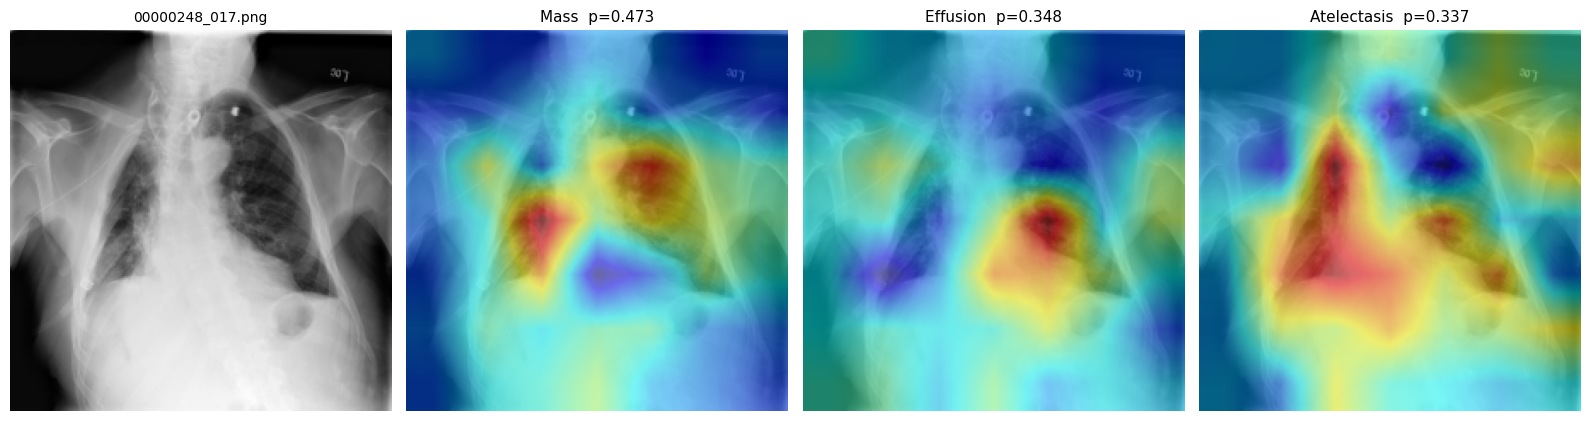

GT: Mass
  Mass                 0.4731
  Effusion             0.3480
  Atelectasis          0.3369
  Pleural_Thickening   0.3352
  Infiltration         0.2854
  Nodule               0.2311
  Consolidation        0.1333
  Emphysema            0.0520
  Cardiomegaly         0.0468
  Pneumothorax         0.0437
  Pneumonia            0.0228
  Fibrosis             0.0199
  Edema                0.0056


In [131]:
# ── chạy thử ──
test_loc = 1020

row = all_xray_df.dropna(subset=["path"]).iloc[test_loc]  #? lấy row từ CHÍNH df đã dropna — iloc trên df gốc trỏ sang ảnh khác vì dropna đánh lại vị trí

print(row[["Finding Labels", "disease_vec"]])  #? row là Series → index bằng list nhãn, không có kwarg columns=

probs = show_cam(row["path"], topk=3)

print("GT:", row["Finding Labels"])
for name, p in sorted(zip(CFG["label_cols"], probs), key=lambda t: -t[1]):
    print(f"  {name:20s} {p:.4f}")